# Medication EDA

`upd23b_clinical_state_on_medication` says whether the patient was On or Off medication
during the UPDRS exam. Medication is used to decrease symptoms, so it can
change the scores even though disease progression remains the same.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

DATA_DIR = Path("../data/raw")

clinical = pd.read_csv(DATA_DIR / "train_clinical_data.csv")
supplemental = pd.read_csv(DATA_DIR / "supplemental_clinical_data.csv")

MED = "upd23b_clinical_state_on_medication"
clinical["med_state"] = clinical[MED].fillna("Missing")
supplemental["med_state"] = supplemental[MED].fillna("Missing")

## Medication Status

In [2]:
print("Clinical")
print(clinical["med_state"].value_counts(normalize=True).mul(100).round(1))

print("\nSupplemental")
print(supplemental["med_state"].value_counts(normalize=True).mul(100).round(1))

Clinical
med_state
Missing    50.7
On         29.6
Off        19.6
Name: proportion, dtype: float64

Supplemental
med_state
Missing    49.5
On         49.2
Off         1.3
Name: proportion, dtype: float64


## Missing by visit month

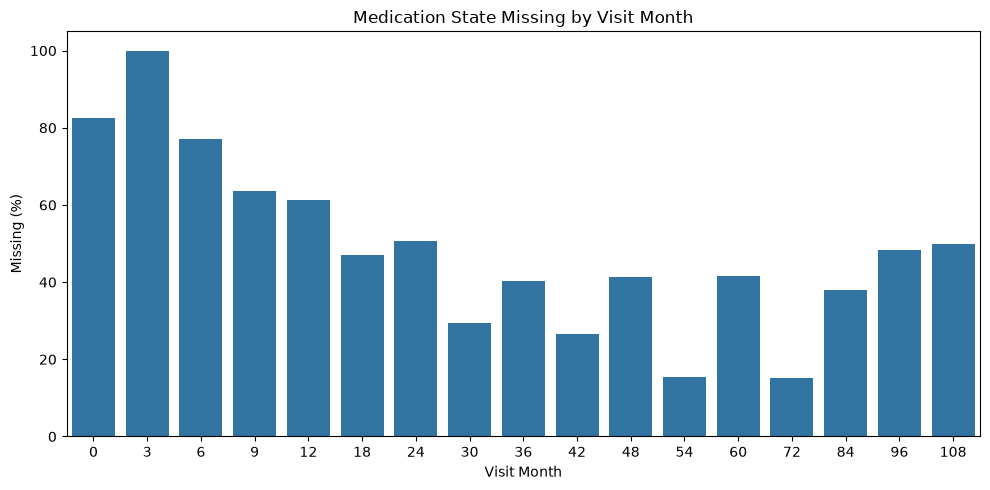

In [3]:
clinical["is_missing"] = clinical[MED].isna()
missing_by_month = clinical.groupby("visit_month")["is_missing"].mean() * 100

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_by_month.index, y=missing_by_month.values)
plt.xlabel("Visit Month")
plt.ylabel("Missing (%)")
plt.title("Medication State Missing by Visit Month")
plt.tight_layout()
plt.show()

## Patients

In [4]:
on = set(clinical.loc[clinical[MED] == "On", "patient_id"])
off = set(clinical.loc[clinical[MED] == "Off", "patient_id"])
all_patients = set(clinical["patient_id"])

print("Clinical Data Summary:")
print("Both On and Off:", len(on & off))
print("Only On:", len(on - off))
print("Only Off:", len(off - on))
print("Never recorded:", len(all_patients - on - off))

Clinical Data Summary:
Both On and Off: 114
Only On: 35
Only Off: 6
Never recorded: 93


## UPDRS by medication state

In [5]:
clinical.groupby("med_state")[["updrs_1", "updrs_2", "updrs_3", "updrs_4"]].mean().round(2)

,updrs_1,updrs_2,updrs_3,updrs_4
med_state,,,,
Missing,4.94,3.82,12.04,0.22
Off,8.76,10.04,30.87,1.99
On,9.73,9.56,24.37,2.45


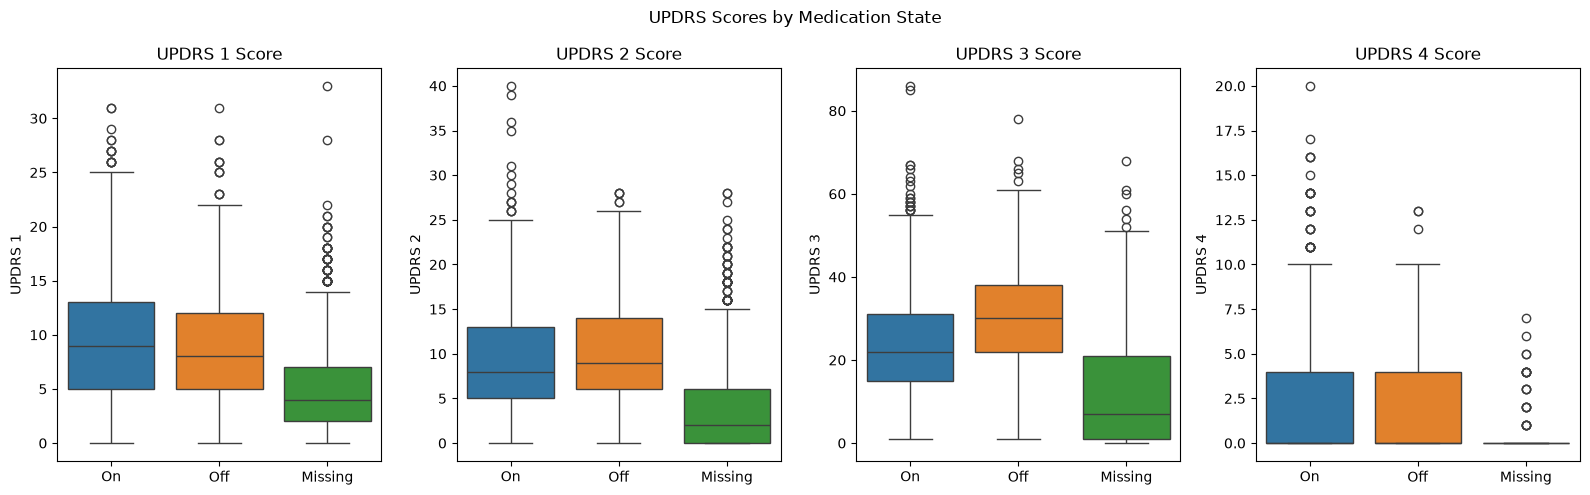

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, ["updrs_1", "updrs_2", "updrs_3", "updrs_4"]):
    sns.boxplot(data=clinical, x="med_state", y=col, order=["On", "Off", "Missing"], ax=ax, hue="med_state", hue_order=["On", "Off", "Missing"])
    ax.set_xlabel("")
    ax.set_ylabel(col.upper().replace("_", " "))
    ax.set_title(col.upper().replace("_", " ") + " Score")

plt.suptitle("UPDRS Scores by Medication State")
plt.tight_layout()
plt.show()

## UPDRS 3 over time

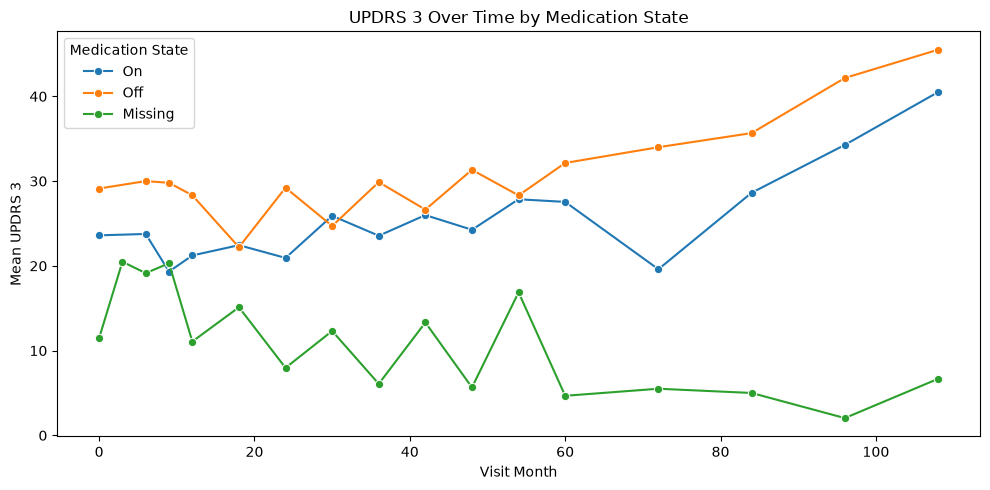

In [25]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=clinical, x="visit_month", y="updrs_3", hue="med_state",
             hue_order=["On", "Off", "Missing"], errorbar=None, marker="o")
plt.xlabel("Visit Month")
plt.ylabel("Mean UPDRS 3")
plt.title("UPDRS 3 Over Time by Medication State")
plt.legend(title="Medication State")
plt.tight_layout()
plt.show()